In [2]:
%pip install scipy

   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
    --------------------------------------- 0.8/37.4 MB 7.8 MB/s eta 0:00:05
   - -------------------------------------- 1.3/37.4 MB 4.1 MB/s eta 0:00:09
   - -------------------------------------- 1.6/37.4 MB 3.6 MB/s eta 0:00:10
   - -------------------------------------- 1.8/37.4 MB 2.6 MB/s eta 0:00:14
   -- ------------------------------------- 2.1/37.4 MB 2.3 MB/s eta 0:00:16
   -- ------------------------------------- 2.4/37.4 MB 2.0 MB/s eta 0:00:18
   -- ------------------------------------- 2.4/37.4 MB 2.0 MB/s eta 0:00:18
   -- ------------------------------------- 2.6/37.4 MB 1.6 MB/s eta 0:00:22
   --- ------------------------------------ 2.9/37.4 MB 1.5 MB/s eta 0:00:23
   --- ------------------------------------ 3.1/37.4 MB 1.5 MB/s eta 0:00:23
   --- ------------------------------------ 3.4/37.4 MB 1.5 MB/s eta 0:00:24
   --- ------------------------------------ 3.4/37.4 MB 1.5 MB/s eta 0:00:24
   ---


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Task 4 environment ready!")

Task 4 environment ready!


In [4]:
df = pd.read_csv("task3_dashboard_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 22)


,Order_ID,Order_Date,Order_Year,Order_Month,Order_Quarter,Order_Weekday,Customer_ID,Customer_Name,Age,Age_Group,...,Product,Category,Quantity,Unit_Price,Total_Sales,Is_Sales_Outlier,Age_Imputed,City_Imputed,Is_Duplicate_ID_Fixed,Customer_Segment
0,ORD100002,2025-02-25,2025,February,1,Tuesday,CUST5529,Customer_227,30,26-35,...,Rice,Grocery,7,2829.77,19808.39,False,False,False,False,Low Value
1,ORD100003,2025-10-14,2025,October,4,Tuesday,CUST3127,Customer_182,63,56-65,...,Book,Education,5,27906.16,139530.80,False,False,False,False,Medium Value
2,ORD100004,2025-05-13,2025,May,2,Tuesday,CUST8887,Customer_487,62,56-65,...,Book,Education,8,37491.06,299928.48,False,False,False,False,High Value
3,ORD100005,2025-12-02,2025,December,4,Tuesday,CUST2515,Customer_470,65,56-65,...,Mobile,Electronics,9,28541.36,256872.24,False,False,False,False,High Value
4,ORD100006,2025-11-20,2025,November,4,Thursday,CUST4796,Customer_380,44,36-45,...,Rice,Grocery,10,14036.59,140365.90,False,False,False,False,Medium Value


In [5]:
male_sales = df[df['Gender'] == 'Male']['Total_Sales']

female_sales = df[df['Gender'] == 'Female']['Total_Sales']

print("Male Orders:", len(male_sales))
print("Female Orders:", len(female_sales))

print("\nMale Average Sales:", round(male_sales.mean(), 2))
print("Female Average Sales:", round(female_sales.mean(), 2))

Male Orders: 511
Female Orders: 489

Male Average Sales: 141807.34
Female Average Sales: 136883.21


In [6]:
t_stat, p_value = stats.ttest_ind(
    male_sales,
    female_sales,
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: 0.6826
P-value: 0.495


In [7]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in average sales by gender.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference in average sales by gender.")

Fail to Reject the Null Hypothesis
There is no statistically significant difference in average sales by gender.


In [9]:
male_var = male_sales.var(ddof=1)
female_var = female_sales.var(ddof=1)

mean_difference = male_sales.mean() - female_sales.mean()

standard_error = np.sqrt(
    male_var / len(male_sales) +
    female_var / len(female_sales)
)

welch_df = (
    (male_var / len(male_sales) + female_var / len(female_sales)) ** 2
    /
    (
        ((male_var / len(male_sales)) ** 2 / (len(male_sales) - 1))
        +
        ((female_var / len(female_sales)) ** 2 / (len(female_sales) - 1))
    )
)

critical_value = stats.t.ppf(0.975, welch_df)

ci_lower = mean_difference - critical_value * standard_error
ci_upper = mean_difference + critical_value * standard_error

print("Mean Difference:", round(mean_difference, 2))
print("95% Confidence Interval:",
      round(ci_lower, 2),
      "to",
      round(ci_upper, 2))

Mean Difference: 4924.13
95% Confidence Interval: -9231.58 to 19079.85


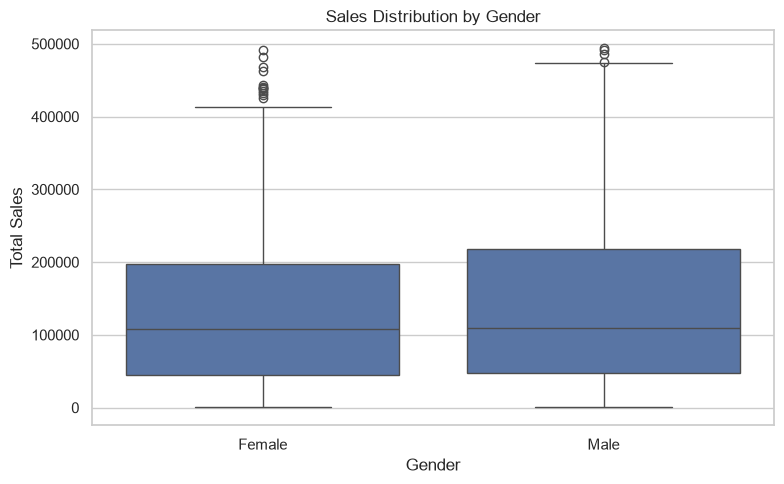

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Total_Sales'
)

plt.title('Sales Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

## Final Business Conclusion

The Welch's independent samples t-test found no statistically significant difference in average order sales between male and female customers.

The p-value was approximately 0.495, which is greater than the significance level of 0.05. Therefore, the null hypothesis was not rejected.

The analysis suggests that gender alone is not a strong predictor of customer spending behavior. The business should focus more on customer value segments, products, categories, and geographic patterns when designing revenue growth strategies.